In [40]:
import pandas as pd
import matplotlib.pyplot as plt


In [41]:

datos_arbolado= pd.read_pickle("../data/datos_arbolado")

datos_arbolado.head()

,long,lat,comuna,manzana,calle_nombre,calle_altura,calle_chapa,nombre_cientifico,ancho_acera,estado_plantera,ubicacion_plantera,nivel_plantera,diametro_altura_pecho,altura_arbol
0,-58.378563,-34.594902,1.0,NaN,Esmeralda,1000,11200,Tipuana tipu,5.5,2.0,Regular,1.0,88.0,34.0
1,-58.381532,-34.592319,1.0,NaN,Pellegrini Carlos,1300,13450,Otra,4.5,2.0,Regular,2.0,6.0,5.0
2,-58.379103,-34.591939,1.0,NaN,Arroyo,800,8480,Fraxinus pennsylvanica,4.0,2.0,Regular,1.0,7.0,6.0
5,-58.381043,-34.591584,1.0,NaN,Arroyo,900,9700,Fraxinus pennsylvanica,3.5,2.0,Regular,1.0,29.0,15.0
6,-58.380968,-34.591576,1.0,NaN,Arroyo,900,9620,Fraxinus pennsylvanica,4.5,2.0,Regular,1.0,21.0,12.0


# Las comunas con mayor densidad de arboles tambien experimentan mayor densidad sobreocupacion.

In [42]:
estado_plantera=datos_arbolado['estado_plantera'].value_counts()
print(estado_plantera)

estado_plantera
2.0    303535
3.0     35135
1.0       170
0.0         2
Name: count, dtype: int64


Text(0, 0.5, 'Cantidad arboles')

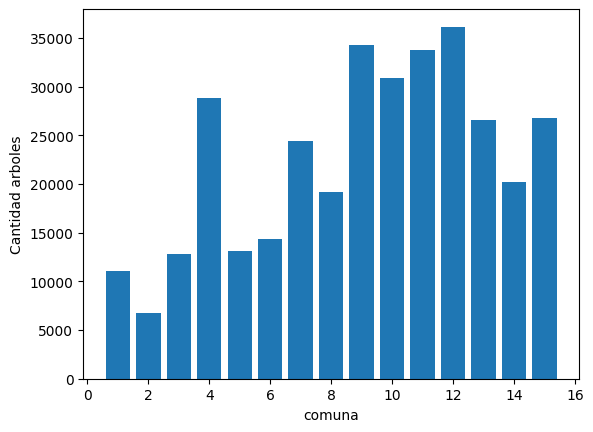

In [46]:
cant_arb= datos_arbolado['comuna'].value_counts()
plt.bar(cant_arb.index, cant_arb.values)
plt.xlabel('comuna')
plt.ylabel('Cantidad arboles')


--- Densidad TOTAL de árboles por comuna (árboles/km²) ---
        densidad_total_arboles  total_arboles  superficie_km2  \
comuna                                                          
10.0               2431.732283          30883            12.7   
11.0               2390.780142          33710            14.1   
15.0               2368.318584          26762            11.3   
4.0                2325.967742          28842            12.4   
12.0               2316.602564          36139            15.6   
6.0                2105.294118          14316             6.8   
9.0                2060.963855          34212            16.6   
3.0                2033.174603          12809             6.3   
7.0                1972.338710          24457            12.4   
5.0                1956.417910          13108             6.7   
13.0               1819.315068          26562            14.6   
2.0                1110.819672           6776             6.1   
14.0               1055.811518

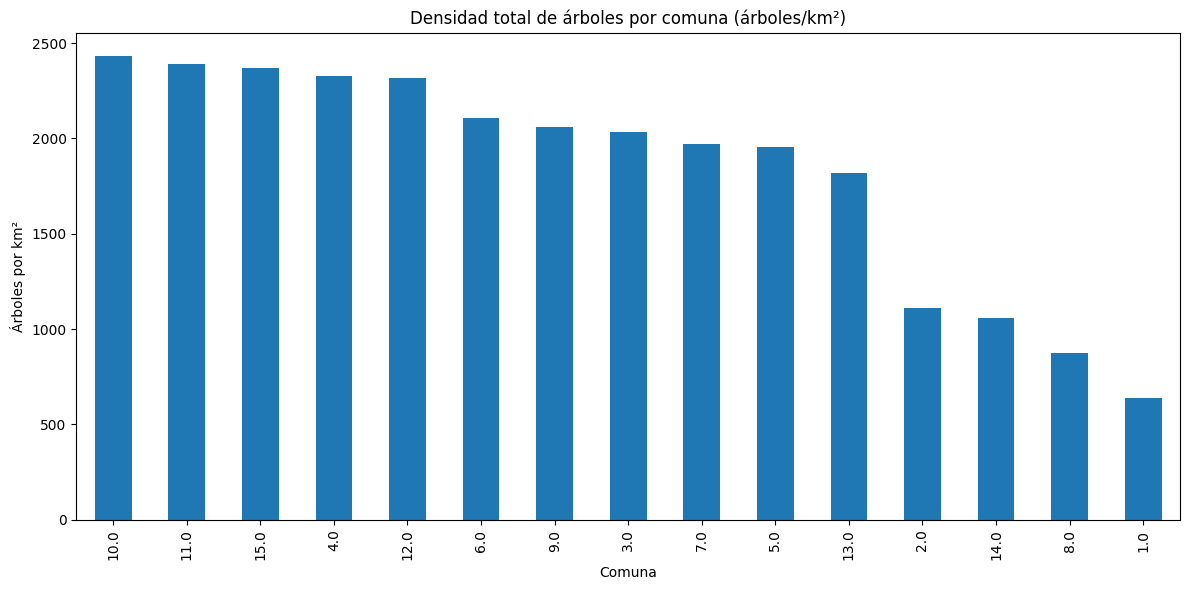

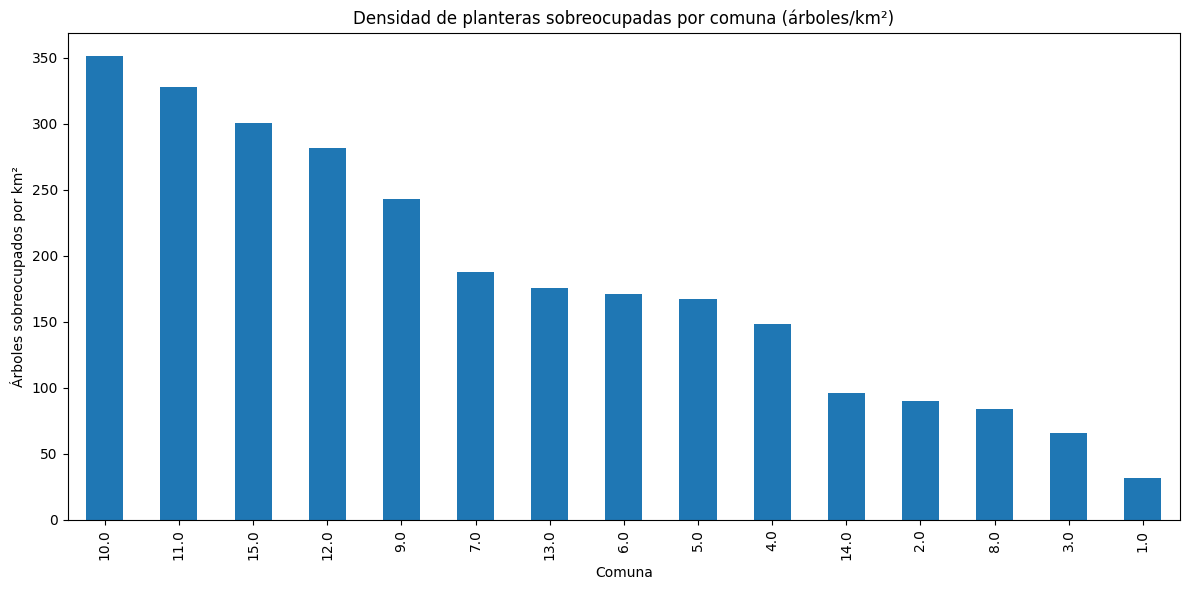

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================
# 0) Configuración y supuestos
# =========================================
# Reemplaza los valores con las superficies oficiales en km².
# Asegúrate de que las claves (1..15) coincidan con la codificación de tu columna 'comuna'.
diccionario_superficies = {
    1: 17.4,  2: 6.1,  3: 6.3,  4: 12.4,  5: 6.7,
    6: 6.8,   7: 12.4, 8: 21.9, 9: 16.6, 10: 12.7,
    11: 14.1, 12: 15.6, 13: 14.6, 14: 19.1, 15: 11.3
}

# Si tus columnas tienen otros nombres, ajusta aquí:
COL_COMUNA = "comuna"
COL_ESTADO = "estado_plantera"   # 3 = sobreocupada (según tu codificación)
COL_ESPECIE = "nombre_cientifico"

# =========================================
# 1) Validaciones rápidas
# =========================================
# Asegura que 'comuna' sea numérica para mapear bien el diccionario.
datos_arbolado = datos_arbolado.copy()
datos_arbolado[COL_COMUNA] = pd.to_numeric(datos_arbolado[COL_COMUNA], errors="coerce")

# Chequeo de claves faltantes en el diccionario de superficies
comunas_presentes = set(datos_arbolado[COL_COMUNA].dropna().unique().astype(int))
faltantes = comunas_presentes.difference(diccionario_superficies.keys())
if faltantes:
    print(f"[ADVERTENCIA] Faltan superficies para estas comunas: {sorted(faltantes)}")
    # Si faltan, no cortamos la ejecución: esas comunas quedarán con NaN en superficie

# =========================================
# 2) Conteos por comuna
# =========================================
conteo_total = datos_arbolado[COL_COMUNA].value_counts().sort_index()
conteo_sobre = (
    datos_arbolado.loc[datos_arbolado[COL_ESTADO] == 3, COL_COMUNA]
    .value_counts()
    .sort_index()
)

# DataFrame base por comuna
df_comunas = pd.DataFrame({
    "total_arboles": conteo_total,
    "sobreocupadas": conteo_sobre
}).fillna(0)

# Mapear superficies
df_comunas["superficie_km2"] = df_comunas.index.map(diccionario_superficies)

# =========================================
# 3) Métricas de densidad y enriquecimiento
# =========================================
# Densidades: árboles por km²
df_comunas["densidad_total_arboles"] = df_comunas["total_arboles"] / df_comunas["superficie_km2"]
df_comunas["densidad_sobreocupadas"] = df_comunas["sobreocupadas"] / df_comunas["superficie_km2"]

# Resumen de especies por comuna (opcional pero útil)
df_resumen = (
    datos_arbolado.groupby(COL_COMUNA)
    .agg(
        cantidad_especies=(COL_ESPECIE, "nunique"),
        cantidad_arboles=(COL_ESPECIE, "count")
    )
)
df_comunas = df_comunas.join(df_resumen, how="left")

# Orden estándar por índice de comuna
df_comunas.index.name = "comuna"
df_comunas = df_comunas.sort_index()

# =========================================
# 4) Tablas ordenadas para inspección
# =========================================
df_orden_total = df_comunas.sort_values("densidad_total_arboles", ascending=False)
df_orden_sobre = df_comunas.sort_values("densidad_sobreocupadas", ascending=False)

print("\n--- Densidad TOTAL de árboles por comuna (árboles/km²) ---")
print(df_orden_total[["densidad_total_arboles", "total_arboles", "superficie_km2", "cantidad_especies"]])

print("\n--- Densidad de PLANTERAS SOBREOCUPADAS por comuna (árboles/km²) ---")
print(df_orden_sobre[["densidad_sobreocupadas", "sobreocupadas", "superficie_km2", "cantidad_especies"]])

# =========================================
# 5) Gráficos (matplotlib, una métrica por figura)
# =========================================

# A) Densidad total de árboles
plt.figure(figsize=(12, 6))
df_orden_total["densidad_total_arboles"].plot(kind="bar")
plt.title("Densidad total de árboles por comuna (árboles/km²)")
plt.xlabel("Comuna")
plt.ylabel("Árboles por km²")
plt.tight_layout()
plt.show()

# B) Densidad de sobreocupación
plt.figure(figsize=(12, 6))
df_orden_sobre["densidad_sobreocupadas"].plot(kind="bar")
plt.title("Densidad de planteras sobreocupadas por comuna (árboles/km²)")
plt.xlabel("Comuna")
plt.ylabel("Árboles sobreocupados por km²")
plt.tight_layout()
plt.show()

# =========================================
# 6) (Opcional) Chequeos de calidad
# =========================================
# Comunas con superficie faltante (NaN) -> sus densidades serán NaN.
comunas_superficie_nan = df_comunas.index[df_comunas["superficie_km2"].isna()].tolist()
if comunas_superficie_nan:
    print(f"\n[AVISO] Hay comunas sin superficie (NaN): {comunas_superficie_nan}. "
          "Completa el diccionario para obtener densidades correctas.")

# (Opcional) Normalización por 1.000 árboles si querés tasas por mil para comunicar
# df_comunas["tasa_sobreocupadas_por_mil"] = 1_000 * df_comunas["sobreocupadas"] / df_comunas["total_arboles"]


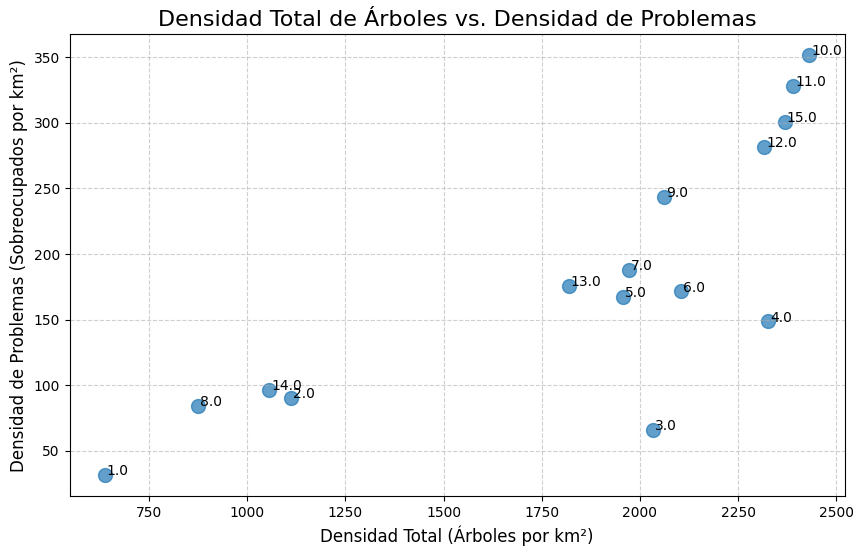

In [58]:
# --- 1. Graficar Densidad Total vs. Densidad de Problema ---
plt.figure(figsize=(10, 6))
plt.scatter(
    df_comunas['densidad_total_arboles'],
    df_comunas['densidad_sobreocupadas'],
    alpha=0.7,
    s=100 # Puntos más grandes
)

plt.title('Densidad Total de Árboles vs. Densidad de Problemas', fontsize=16)
plt.xlabel('Densidad Total (Árboles por km²)', fontsize=12)
plt.ylabel('Densidad de Problemas (Sobreocupados por km²)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# (Opcional) Añadir etiquetas a los puntos
for i, row in df_comunas.iterrows():
    plt.text(row['densidad_total_arboles'] + 5, row['densidad_sobreocupadas'], str(i))

plt.show()

In [60]:
import numpy as np
from scipy import stats

datos_columna1= df_comunas['densidad_total_arboles']
datos_columna2= df_comunas['densidad_sobreocupadas']

# calcular la correlación de Pearson usando NumPy
#coeficiente_correlacion = np.corrcoef(datos_columna1, datos_columna2)[0, 1]
#print(coeficiente_correlacion)

# alternativamente, se puede usar SciPy:
coeficiente_correlacion, _ = stats.pearsonr(datos_columna1, datos_columna2)
print(f"Correlación entre densidad total arboles y densidad arboles con plantera sobreocupada: {coeficiente_correlacion:.4f}")


Correlación entre densidad total arboles y densidad arboles con plantera sobreocupada: 0.7921
